# Reproducible Structural Comparison Analysis

This notebook reproduces the main structural-comparison and statistical analyses of the project using previously validated residue-mapping tables.

## Analysis workflow

1. Load validated UniProt–PDB residue mappings.
2. Extract experimental and AlphaFold Cα coordinates.
3. Pair corresponding residues.
4. Perform Kabsch structural superposition.
5. Calculate global Cα RMSD.
6. Calculate per-residue Cα deviation.
7. Extract AlphaFold pLDDT.
8. Calculate Spearman correlations between pLDDT and structural deviation.
9. Examine ADK domain-level deviation patterns.
10. Generate summary tables and figures.

The workflow deliberately uses a lightweight pure-Python PDB parser for coordinate extraction rather than `Bio.PDB`, improving compatibility with the current Windows execution environment.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Cannot locate project root.")


EXP_DIR = PROJECT_ROOT / "data" / "raw" / "experimental"
AF_DIR = PROJECT_ROOT / "data" / "raw" / "alphafold"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"


print("Project root:", PROJECT_ROOT)
print("Environment ready.")

Project root: C:\Users\kokoc\Documents\alphafold-pdb-confidence-analysis
Environment ready.


In [2]:
protein_configs = {
    "CA2": {
        "uniprot_id": "P00918",
        "experimental_pdb": EXP_DIR / "2CBA.pdb",
        "experimental_chain": "A",
        "alphafold_pdb": AF_DIR / "AF-P00918-F1-model.pdb",
        "mapping_file": PROCESSED_DIR / "CA2_residue_mapping.csv"
    },
    "TXN": {
        "uniprot_id": "P10599",
        "experimental_pdb": EXP_DIR / "1ERT.pdb",
        "experimental_chain": "A",
        "alphafold_pdb": AF_DIR / "AF-P10599-F1-model.pdb",
        "mapping_file": PROCESSED_DIR / "TXN_residue_mapping.csv"
    },
    "ADK": {
        "uniprot_id": "P69441",
        "experimental_pdb": EXP_DIR / "4AKE.pdb",
        "experimental_chain": "A",
        "alphafold_pdb": AF_DIR / "AF-P69441-F1-model.pdb",
        "mapping_file": PROCESSED_DIR / "ADK_residue_mapping.csv"
    }
}


for protein, config in protein_configs.items():
    print(protein)

    for key in [
        "experimental_pdb",
        "alphafold_pdb",
        "mapping_file"
    ]:
        print(
            " ",
            key,
            "OK" if config[key].exists() else "MISSING"
        )

CA2
  experimental_pdb OK
  alphafold_pdb OK
  mapping_file OK
TXN
  experimental_pdb OK
  alphafold_pdb OK
  mapping_file OK
ADK
  experimental_pdb OK
  alphafold_pdb OK
  mapping_file OK


## Cα coordinate extraction

PDB files use fixed-width text fields. For this analysis, only Cα atoms are required.

The parser below extracts residue identifiers, Cartesian coordinates, occupancy, and the B-factor field. For AlphaFold PDB files, the B-factor field stores residue-level pLDDT values.

In [3]:
def read_ca_atoms(pdb_path, chain_id=None):
    rows = []

    with open(
        pdb_path,
        "r",
        encoding="utf-8",
        errors="replace"
    ) as handle:

        for line in handle:

            if not line.startswith("ATOM"):
                continue

            atom_name = line[12:16].strip()
            altloc = line[16].strip()
            chain = line[21].strip()

            if atom_name != "CA":
                continue

            if altloc not in ("", "A"):
                continue

            if chain_id is not None and chain != chain_id:
                continue

            rows.append({
                "residue_name": line[17:20].strip(),
                "chain": chain,
                "residue_number": int(line[22:26]),
                "insertion_code": line[26].strip(),
                "x": float(line[30:38]),
                "y": float(line[38:46]),
                "z": float(line[46:54]),
                "occupancy": float(line[54:60]),
                "bfactor": float(line[60:66])
            })

    ca_df = pd.DataFrame(rows)

    if ca_df.empty:
        raise ValueError(
            f"No Cα atoms found in {pdb_path.name}"
        )

    return ca_df

## Kabsch structural superposition

Corresponding AlphaFold and experimental Cα coordinates must first be placed in a common coordinate frame.

The Kabsch algorithm removes rigid-body translation and finds the optimal rotation that minimizes the squared distances between corresponding Cα atoms.

After superposition, the remaining distances reflect internal structural disagreement rather than arbitrary differences in coordinate position or orientation.

In [4]:
def kabsch_superpose(mobile_xyz, reference_xyz):

    if mobile_xyz.shape != reference_xyz.shape:
        raise ValueError(
            "Mobile and reference coordinate arrays "
            "must have identical shapes."
        )

    mobile_centroid = mobile_xyz.mean(axis=0)
    reference_centroid = reference_xyz.mean(axis=0)

    mobile_centered = (
        mobile_xyz - mobile_centroid
    )

    reference_centered = (
        reference_xyz - reference_centroid
    )

    covariance = (
        mobile_centered.T
        @ reference_centered
    )

    U, singular_values, Vt = np.linalg.svd(
        covariance
    )

    rotation = U @ Vt

    if np.linalg.det(rotation) < 0:
        Vt[-1, :] *= -1
        rotation = U @ Vt

    mobile_aligned = (
        mobile_centered
        @ rotation
        + reference_centroid
    )

    return mobile_aligned, rotation

In [5]:
for protein, config in protein_configs.items():

    exp_ca = read_ca_atoms(
        config["experimental_pdb"],
        chain_id=config["experimental_chain"]
    )

    af_ca = read_ca_atoms(
        config["alphafold_pdb"],
        chain_id="A"
    )

    print(
        protein,
        "| experimental Cα =", len(exp_ca),
        "| AlphaFold Cα =", len(af_ca)
    )

CA2 | experimental Cα = 258 | AlphaFold Cα = 260
TXN | experimental Cα = 105 | AlphaFold Cα = 105
ADK | experimental Cα = 214 | AlphaFold Cα = 214


## Residue pairing and structural comparison

Validated UniProt–PDB residue-mapping tables are used to connect experimental PDB residues with the corresponding UniProt positions.

Experimental and AlphaFold Cα coordinates are then paired by biological residue identity. The AlphaFold coordinates are superimposed onto the experimental coordinates using the Kabsch algorithm.

For each protein, the workflow calculates:

- number of paired residues
- RMSD before superposition
- global Cα RMSD after superposition
- per-residue Cα deviation
- AlphaFold pLDDT

In [6]:
def analyze_structure_pair(
    uniprot_id,
    experimental_pdb,
    experimental_chain,
    alphafold_pdb,
    mapping_file
):
    # Read Cα atoms
    exp_ca = read_ca_atoms(
        experimental_pdb,
        chain_id=experimental_chain
    )

    af_ca = read_ca_atoms(
        alphafold_pdb,
        chain_id="A"
    )

    # Load validated residue mapping
    mapping = pd.read_csv(mapping_file)

    mapping["pdb_insertion_code"] = (
        mapping["pdb_insertion_code"]
        .fillna("")
    )

    # Prepare experimental coordinates
    exp_coords = exp_ca[
        [
            "residue_name",
            "residue_number",
            "insertion_code",
            "x",
            "y",
            "z"
        ]
    ].copy()

    exp_coords = exp_coords.rename(
        columns={
            "residue_name": "exp_residue_name",
            "residue_number": "pdb_residue_number",
            "insertion_code": "pdb_insertion_code",
            "x": "exp_x",
            "y": "exp_y",
            "z": "exp_z"
        }
    )

    exp_coords["pdb_insertion_code"] = (
        exp_coords["pdb_insertion_code"]
        .fillna("")
    )

    # Join residue mapping with experimental Cα coordinates
    analysis = mapping.merge(
        exp_coords,
        on=[
            "pdb_residue_number",
            "pdb_insertion_code"
        ],
        how="left",
        validate="one_to_one"
    )

    # Prepare AlphaFold coordinates and pLDDT
    af_coords = af_ca[
        [
            "residue_name",
            "residue_number",
            "x",
            "y",
            "z",
            "bfactor"
        ]
    ].copy()

    af_coords = af_coords.rename(
        columns={
            "residue_name": "af_residue_name",
            "residue_number": "uniprot_position",
            "x": "af_x",
            "y": "af_y",
            "z": "af_z",
            "bfactor": "plddt"
        }
    )

    # Join AlphaFold coordinates using UniProt position
    analysis = analysis.merge(
        af_coords,
        on="uniprot_position",
        how="left",
        validate="one_to_one"
    )

    # QC
    required_columns = [
        "exp_x", "exp_y", "exp_z",
        "af_x", "af_y", "af_z",
        "plddt"
    ]

    if analysis[required_columns].isna().any().any():
        raise ValueError(
            f"{uniprot_id}: missing coordinates or pLDDT"
        )

    if not analysis["uniprot_position"].is_unique:
        raise ValueError(
            f"{uniprot_id}: duplicate UniProt positions"
        )

    # Convert coordinate tables to NumPy arrays
    exp_xyz = analysis[
        ["exp_x", "exp_y", "exp_z"]
    ].to_numpy(dtype=float)

    af_xyz = analysis[
        ["af_x", "af_y", "af_z"]
    ].to_numpy(dtype=float)

    # RMSD before superposition
    raw_rmsd = np.sqrt(
        np.mean(
            np.sum(
                (af_xyz - exp_xyz) ** 2,
                axis=1
            )
        )
    )

    # Kabsch superposition
    af_aligned, rotation = kabsch_superpose(
        af_xyz,
        exp_xyz
    )

    # Per-residue Cα deviation
    analysis["ca_deviation"] = np.sqrt(
        np.sum(
            (af_aligned - exp_xyz) ** 2,
            axis=1
        )
    )

    # Global RMSD after superposition
    global_rmsd = np.sqrt(
        np.mean(
            analysis["ca_deviation"] ** 2
        )
    )

    return {
        "uniprot_id": uniprot_id,
        "n_pairs": len(analysis),
        "raw_rmsd": raw_rmsd,
        "global_rmsd": global_rmsd,
        "rotation_determinant": np.linalg.det(rotation),
        "analysis": analysis
    }

In [7]:
structure_results = {}

for protein, config in protein_configs.items():

    result = analyze_structure_pair(
        **config
    )

    structure_results[protein] = result

    print(
        protein,
        "| pairs =", result["n_pairs"],
        "| raw RMSD =", round(result["raw_rmsd"], 3),
        "| aligned RMSD =", round(result["global_rmsd"], 3),
        "Å",
        "| det(R) =", round(
            result["rotation_determinant"],
            6
        )
    )

CA2 | pairs = 258 | raw RMSD = 33.124 | aligned RMSD = 0.531 Å | det(R) = 1.0
TXN | pairs = 105 | raw RMSD = 47.042 | aligned RMSD = 0.384 Å | det(R) = 1.0
ADK | pairs = 214 | raw RMSD = 23.536 | aligned RMSD = 7.2 Å | det(R) = 1.0


## pLDDT–deviation correlation

Spearman rank correlation is used to evaluate whether residues with higher AlphaFold pLDDT tend to show smaller Cα deviations from the selected experimental structure.

Spearman correlation evaluates a monotonic rank relationship and does not assume that the relationship is linear.

In [8]:
correlation_results = []

for protein, result in structure_results.items():

    df = result["analysis"]

    rho, p_value = spearmanr(
        df["plddt"],
        df["ca_deviation"]
    )

    correlation_results.append({
        "protein": protein,
        "n_residues": len(df),
        "spearman_rho": rho,
        "p_value": p_value,
        "mean_plddt": df["plddt"].mean(),
        "median_deviation": df["ca_deviation"].median(),
        "mean_deviation": df["ca_deviation"].mean()
    })

correlation_summary_df = pd.DataFrame(
    correlation_results
)

display(correlation_summary_df)

,protein,n_residues,spearman_rho,p_value,mean_plddt,median_deviation,mean_deviation
0,CA2,258,-0.421364,1.582887e-12,97.779612,0.260633,0.321138
1,TXN,105,-0.481014,2.059743e-07,97.591429,0.286919,0.339610
2,ADK,214,-0.585405,4.467195e-21,95.917150,4.365448,5.831522


In [9]:
rmsd_summary = []

for protein, result in structure_results.items():

    rmsd_summary.append({
        "protein": protein,
        "uniprot_id": result["uniprot_id"],
        "paired_residues": result["n_pairs"],
        "raw_rmsd": result["raw_rmsd"],
        "aligned_ca_rmsd": result["global_rmsd"],
        "rotation_determinant": result[
            "rotation_determinant"
        ]
    })

rmsd_summary_df = pd.DataFrame(
    rmsd_summary
)

display(rmsd_summary_df)

,protein,uniprot_id,paired_residues,raw_rmsd,aligned_ca_rmsd,rotation_determinant
0,CA2,P00918,258,33.124188,0.531232,1.0
1,TXN,P10599,105,47.042479,0.384446,1.0
2,ADK,P69441,214,23.536265,7.200427,1.0


## ADK domain-level analysis

Adenylate kinase showed substantially larger structural disagreement than CA2 and TXN.

To examine whether this disagreement is uniformly distributed or concentrated in specific regions, ADK residues are grouped into CORE, NMP, and LID regions.

For this exploratory analysis:

- NMP: residues 30–67
- LID: residues 118–160
- CORE: remaining residues

The analysis compares residue-level Cα deviation among these regions.

In [10]:
def assign_adk_domain(position):

    if 30 <= position <= 67:
        return "NMP"

    elif 118 <= position <= 160:
        return "LID"

    else:
        return "CORE"

In [11]:
adk_df = (
    structure_results["ADK"]["analysis"]
    .copy()
)

adk_df["domain"] = (
    adk_df["uniprot_position"]
    .apply(assign_adk_domain)
)

adk_domain_summary = (
    adk_df
    .groupby("domain")
    .agg(
        n_residues=(
            "uniprot_position",
            "count"
        ),
        mean_deviation=(
            "ca_deviation",
            "mean"
        ),
        median_deviation=(
            "ca_deviation",
            "median"
        ),
        max_deviation=(
            "ca_deviation",
            "max"
        ),
        mean_plddt=(
            "plddt",
            "mean"
        )
    )
    .reset_index()
)

display(adk_domain_summary)

,domain,n_residues,mean_deviation,median_deviation,max_deviation,mean_plddt
0,CORE,133,3.419530,3.369512,6.270688,96.549023
1,LID,43,10.555471,10.451518,18.444037,94.100465
2,NMP,38,8.927971,9.846015,15.845950,95.761316


In [12]:
adk_threshold = (
    adk_df["ca_deviation"]
    .quantile(0.90)
)

adk_high_dev = adk_df[
    adk_df["ca_deviation"] >= adk_threshold
].copy()

domain_outlier_counts = (
    adk_high_dev["domain"]
    .value_counts()
)

print(
    "ADK 90th percentile deviation threshold:",
    round(adk_threshold, 3),
    "Å"
)

display(domain_outlier_counts)

ADK 90th percentile deviation threshold: 13.17 Å


domain
LID    13
NMP     9
Name: count, dtype: int64

In [13]:
outlier_results = []

for protein, result in structure_results.items():

    df = result["analysis"].copy()

    deviation_threshold = (
        df["ca_deviation"]
        .quantile(0.90)
    )

    outliers = df[
        (df["plddt"] >= 90) &
        (
            df["ca_deviation"]
            >= deviation_threshold
        )
    ].copy()

    outliers["protein"] = protein

    outliers["deviation_threshold"] = (
        deviation_threshold
    )

    outlier_results.append(outliers)


high_confidence_outliers_df = pd.concat(
    outlier_results,
    ignore_index=True
)

outlier_counts = (
    high_confidence_outliers_df
    .groupby("protein")
    .size()
)

display(outlier_counts)

protein
ADK    21
CA2    24
TXN    11
dtype: int64

## Save reproducible analysis outputs

The following cells save the main residue-level datasets and summary tables generated by this notebook.

In [14]:
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Residue-level structural comparison tables
for protein, result in structure_results.items():

    output_file = (
        PROCESSED_DIR /
        f"{protein}_structure_comparison.csv"
    )

    result["analysis"].to_csv(
        output_file,
        index=False
    )

# Summary tables
rmsd_summary_df.to_csv(
    TABLE_DIR / "rmsd_summary.csv",
    index=False
)

correlation_summary_df.to_csv(
    TABLE_DIR / "correlation_summary.csv",
    index=False
)

adk_domain_summary.to_csv(
    TABLE_DIR / "ADK_domain_summary.csv",
    index=False
)

adk_high_dev.to_csv(
    TABLE_DIR /
    "ADK_top10_percent_deviation_residues.csv",
    index=False
)

high_confidence_outliers_df.to_csv(
    TABLE_DIR /
    "high_confidence_high_deviation_residues.csv",
    index=False
)

print("Tables saved successfully.")

Tables saved successfully.


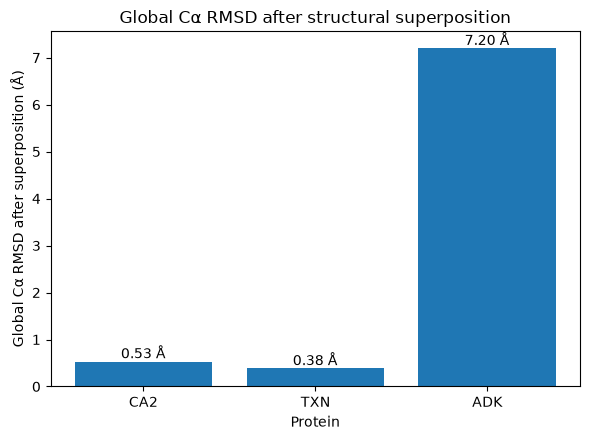

In [15]:
plt.figure(figsize=(6, 4.5))

bars = plt.bar(
    rmsd_summary_df["protein"],
    rmsd_summary_df["aligned_ca_rmsd"]
)

plt.xlabel("Protein")
plt.ylabel("Global Cα RMSD after superposition (Å)")
plt.title("Global Cα RMSD after structural superposition")

for bar, value in zip(
    bars,
    rmsd_summary_df["aligned_ca_rmsd"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f} Å",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "global_rmsd_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

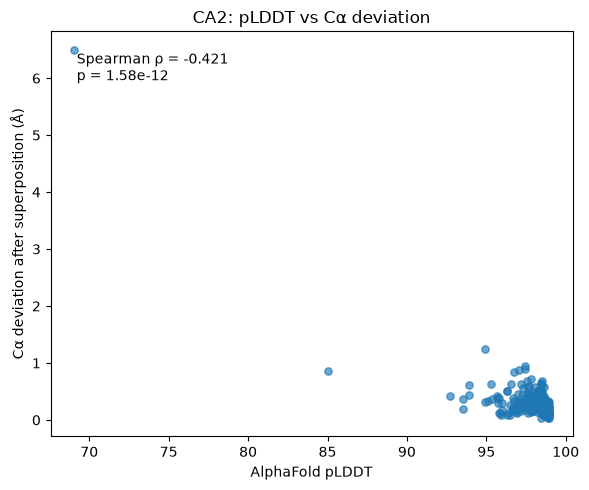

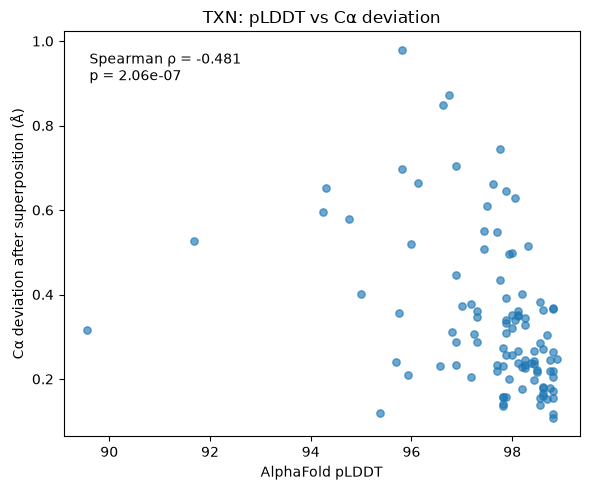

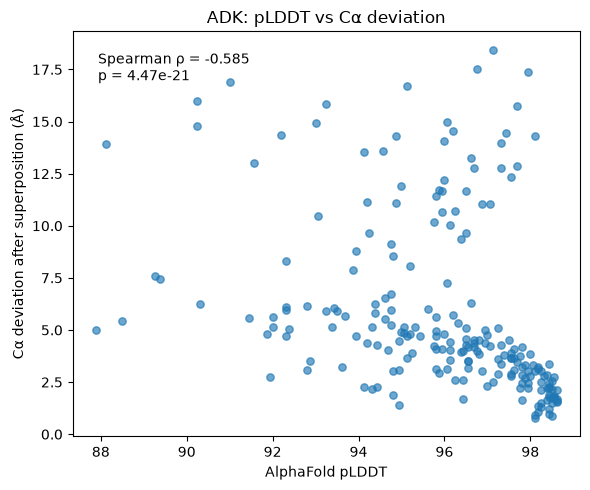

In [16]:
correlation_lookup = (
    correlation_summary_df
    .set_index("protein")
)

for protein, result in structure_results.items():

    df = result["analysis"]

    rho = correlation_lookup.loc[
        protein,
        "spearman_rho"
    ]

    p_value = correlation_lookup.loc[
        protein,
        "p_value"
    ]

    plt.figure(figsize=(6, 5))

    plt.scatter(
        df["plddt"],
        df["ca_deviation"],
        alpha=0.65,
        s=28
    )

    plt.xlabel("AlphaFold pLDDT")
    plt.ylabel(
        "Cα deviation after superposition (Å)"
    )

    plt.title(
        f"{protein}: pLDDT vs Cα deviation"
    )

    plt.text(
        0.05,
        0.95,
        f"Spearman ρ = {rho:.3f}\n"
        f"p = {p_value:.2e}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR /
        f"{protein}_plddt_vs_deviation.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

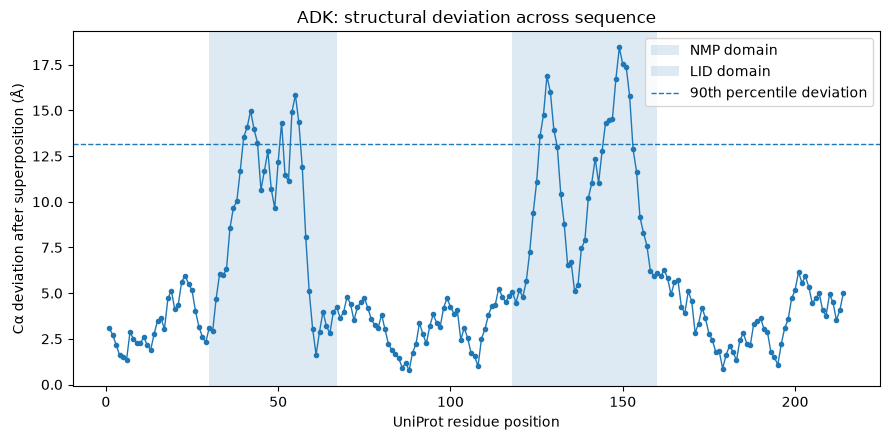

In [17]:
plt.figure(figsize=(9, 4.5))

plt.plot(
    adk_df["uniprot_position"],
    adk_df["ca_deviation"],
    marker="o",
    markersize=3,
    linewidth=1
)

plt.axvspan(
    30,
    67,
    alpha=0.15,
    label="NMP domain"
)

plt.axvspan(
    118,
    160,
    alpha=0.15,
    label="LID domain"
)

plt.axhline(
    adk_threshold,
    linestyle="--",
    linewidth=1,
    label="90th percentile deviation"
)

plt.xlabel("UniProt residue position")
plt.ylabel(
    "Cα deviation after superposition (Å)"
)
plt.title(
    "ADK: structural deviation across sequence"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "ADK_deviation_by_domain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Reproducibility checks

The following assertions verify that the clean workflow reproduces the principal numerical results obtained during project development.

In [18]:
expected_rmsd = {
    "CA2": 0.5312317195,
    "TXN": 0.384,
    "ADK": 7.200
}

expected_rho = {
    "CA2": -0.421364,
    "TXN": -0.481014,
    "ADK": -0.585405
}


for protein, expected in expected_rmsd.items():

    observed = (
        structure_results[protein]
        ["global_rmsd"]
    )

    assert np.isclose(
        observed,
        expected,
        atol=0.01
    ), (
        f"{protein}: unexpected RMSD "
        f"{observed}"
    )


for protein, expected in expected_rho.items():

    observed = (
        correlation_summary_df
        .set_index("protein")
        .loc[protein, "spearman_rho"]
    )

    assert np.isclose(
        observed,
        expected,
        atol=0.001
    ), (
        f"{protein}: unexpected Spearman rho "
        f"{observed}"
    )


assert len(adk_high_dev) == 22

assert (
    (adk_high_dev["domain"] == "CORE")
    .sum()
    == 0
)

print("All reproducibility checks passed.")

All reproducibility checks passed.
